In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

# craete a llm
llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    profile={
        "max_input_tokens":131072
    }
)

# create a state type
class State(TypedDict):
    messages: Annotated[list, add_messages]

# create node (say chatbot)
def chatbot(state: State)->str:
    return {"messages": [llm.invoke(state["messages"])]}

# create graph builder
graph_builder = StateGraph(State)

# bind with nodes
graph_builder.add_node("Chat_Bot_Node", chatbot)

# craete edges
graph_builder.add_edge(START, "Chat_Bot_Node")
graph_builder.add_edge("Chat_Bot_Node", END)

# compile the graph
graph = graph_builder.compile()

In [12]:
llm.invoke("test")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input**: The user simply typed "test". This is a minimal input, often used to check if a system is working, responsive, or to start a conversation without a specific query.\n\n2.  **Identify Intent**: The intent is likely just to verify functionality or to prompt a response. There\'s no specific question or task.\n\n3.  **Determine Response Strategy**: \n   - Acknowledge the input\n   - Confirm functionality\n   - Offer assistance\n   - Keep it concise and friendly\n   - Match the tone (neutral/professional)\n\n4.  **Draft Response**: "Got it! The system is working. How can I assist you today?" or "Test received! Everything looks good on my end. What can I help you with?"\n\n5.  **Refine Response**: Keep it simple and open-ended. "Test received! ✅ Everything’s working. How can I help you today?"\n\n6.  **Final Check**: Matches intent, confirms functionality, invites next step, appropriate tone. Ready.✅\n</t

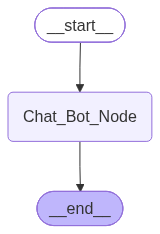

In [ ]:
# Display the Graph

from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)